In [22]:
import json
import pandas as pd
from pandas import json_normalize
import numpy as np

In [23]:
with open('../data/friends_info.json', 'r', encoding='utf-8') as file:
    data = json.load(file)

ids = list(data.keys())
records = list(data.values())

df = json_normalize(records, sep='_')
df['user_id'] = ids
df.set_index('user_id', inplace=True)

df.to_csv('../data/friends_info.csv', encoding='utf-8', index=True)
print('Saved to data/friends_info.csv')


Saved to data/friends_info.csv


In [24]:
dataset = pd.read_csv('../data/friends_info.csv')
dataset.head()

,user_id,basic_info_id,basic_info_first_name,basic_info_last_name,basic_info_domain,basic_info_is_closed,demographics_sex,demographics_birth_date,demographics_age,demographics_city,...,interests_activities,interests_interests,interests_music,interests_movies,interests_books,interests_games,metadata_data_retrieved,metadata_has_education,metadata_has_career,metadata_interests_count
0,342243498,342243498,Даниэль,Вертьянов,NaN,False,мужской,16.5,NaN,Москва,...,NaN,NaN,NaN,NaN,NaN,NaN,2025-11-14T18:35:06.933111,False,False,0
1,419168599,419168599,Александр,Корольков,NaN,False,мужской,16.5,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,2025-11-14T18:35:42.252661,False,False,0
2,171888881,171888881,Денис,Шпинёв,NaN,False,мужской,25.4.2002,23.0,Одинцово,...,NaN,NaN,NaN,NaN,NaN,NaN,2025-11-14T18:35:24.447095,False,False,0
3,457226450,457226450,Алина,Крылова,NaN,False,женский,4.8,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,2025-11-14T18:34:23.112205,False,False,0
4,112120311,112120311,Артур,Дворецкий,NaN,False,мужской,24.11,NaN,Москва,...,NaN,NaN,NaN,NaN,NaN,NaN,2025-11-14T18:35:24.636476,False,False,0


In [25]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 117 entries, 0 to 116
Data columns (total 30 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   user_id                                117 non-null    int64  
 1   basic_info_id                          117 non-null    int64  
 2   basic_info_first_name                  117 non-null    object 
 3   basic_info_last_name                   117 non-null    object 
 4   basic_info_domain                      0 non-null      float64
 5   basic_info_is_closed                   117 non-null    bool   
 6   demographics_sex                       117 non-null    object 
 7   demographics_birth_date                101 non-null    object 
 8   demographics_age                       48 non-null     float64
 9   demographics_city                      79 non-null     object 
 10  demographics_country                   93 non-null     object 
 11  educat

In [26]:
null_col = ['basic_info_domain', 'social_connections_skype', 'social_connections_facebook', 'social_connections_twitter', 'social_connections_instagram']
useless_col = ['basic_info_first_name', 'basic_info_last_name', 'basic_info_is_closed', 'demographics_birth_date', 'demographics_country', 'education_career_education_graduation',
               'education_career_career', 'education_career_universities', 'metadata_data_retrieved', 'metadata_has_education', 'metadata_has_career',
               'interests_activities', 'interests_interests', 'interests_music', 'interests_movies', 'interests_books', 'interests_games', 'metadata_interests_count', 'basic_info_id']

In [27]:
dataset = dataset.drop(columns=null_col)
dataset = dataset.drop(columns=useless_col)

In [28]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 117 entries, 0 to 116
Data columns (total 6 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   user_id                                117 non-null    int64  
 1   demographics_sex                       117 non-null    object 
 2   demographics_age                       48 non-null     float64
 3   demographics_city                      79 non-null     object 
 4   education_career_education_university  35 non-null     object 
 5   education_career_education_faculty     20 non-null     object 
dtypes: float64(1), int64(1), object(4)
memory usage: 5.6+ KB


<Axes: >

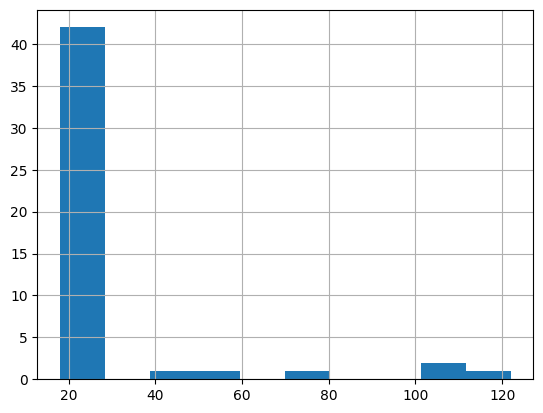

In [29]:
dataset['demographics_age'].hist()

In [30]:
dataset = dataset.loc[(dataset['demographics_age'] < 90) | (dataset['demographics_age'].isna())]

<Axes: >

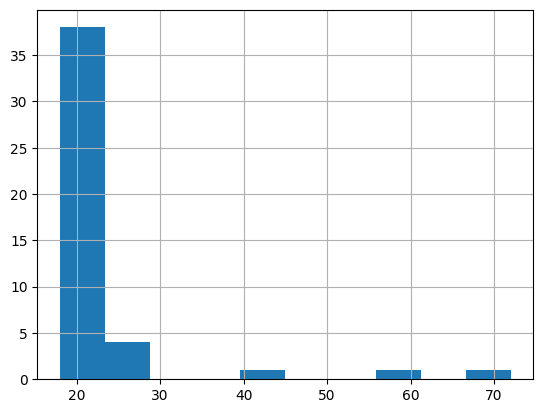

In [31]:
dataset['demographics_age'].hist()

In [32]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 114 entries, 0 to 116
Data columns (total 6 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   user_id                                114 non-null    int64  
 1   demographics_sex                       114 non-null    object 
 2   demographics_age                       45 non-null     float64
 3   demographics_city                      78 non-null     object 
 4   education_career_education_university  34 non-null     object 
 5   education_career_education_faculty     20 non-null     object 
dtypes: float64(1), int64(1), object(4)
memory usage: 6.2+ KB


In [33]:
median_age = np.quantile(dataset['demographics_age'].dropna().values, q=0.5)

dataset['demographics_age'] = dataset['demographics_age'].fillna(median_age)

In [34]:
median_age

np.float64(22.0)

In [35]:
dataset['demographics_city'] = dataset['demographics_city'].fillna('Москва')
dataset['education_career_education_faculty'] = dataset['education_career_education_faculty'].fillna('Неизвестно')
dataset['education_career_education_university'] = dataset['education_career_education_university'].fillna('Неизвестно')

In [36]:
dataset['education_career_education_faculty'].value_counts()

education_career_education_faculty
Неизвестно                                                                  94
Институт информационных технологий                                          14
Институт кибербезопасности и цифровых технологий                             1
Факультет бизнеса «Капитаны»                                                 1
Институт высоких технологий                                                  1
Философский                                                                  1
Факультет информационных технологий                                          1
Факультет химико-фармацевтических технологий и биомедицинских препаратов     1
Name: count, dtype: int64

In [37]:
dataset['education_career_education_university'].value_counts()

education_career_education_university
Неизвестно                                     80
РТУ МИРЭА                                      24
МГТУ им. Н. Э. Баумана (бывш. МВТУ)             2
РХТУ им. Д. И. Менделеева                       2
РЭУ им. Г. В. Плеханова                         1
МГИМО МИД России                                1
МГУПИ                                           1
МГУ                                             1
Президентская академия (РАНХиГС, бывш. АНХ)     1
МИРЭА (до 2015)                                 1
Name: count, dtype: int64

In [38]:
dataset['demographics_city'].value_counts()

demographics_city
Москва              85
Химки                9
Санкт-Петербург      2
Кизнер (поселок)     1
Одинцово             1
Таганрог             1
Fukuoka              1
Старый Оскол         1
Минск                1
Toronto              1
Жуковский            1
Королёв              1
Berlin               1
Ōfunato              1
Евпатория            1
Рязань               1
Paris                1
Пенза                1
Барнаул              1
Подольск             1
Бронницы             1
Name: count, dtype: int64

In [39]:
dataset['demographics_sex'].value_counts()

demographics_sex
мужской    86
женский    28
Name: count, dtype: int64

In [40]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 114 entries, 0 to 116
Data columns (total 6 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   user_id                                114 non-null    int64  
 1   demographics_sex                       114 non-null    object 
 2   demographics_age                       114 non-null    float64
 3   demographics_city                      114 non-null    object 
 4   education_career_education_university  114 non-null    object 
 5   education_career_education_faculty     114 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 6.2+ KB


In [41]:
dataset.to_csv('../data/raw_friends_features.csv', index=False, encoding='utf-8')


In [42]:
import os, json, random
import pandas as pd

random.seed(42)

raw_path = '../data/raw_friends_features.csv'
map_path = '../data/friends_map.json'
out_path = '../data/friends_features.csv'

neg_per_user = 3

df_users = pd.read_csv(raw_path, dtype=str)
df_users['user_id'] = df_users['user_id'].astype(str)
all_users = set(df_users['user_id'].tolist())

with open(map_path, 'r', encoding='utf-8') as f:
    fmap = json.load(f)

fmap = {str(k): [str(v) for v in vals] for k, vals in fmap.items()}

rows = []
for u, friends in fmap.items():
    if u not in all_users:
        continue
    for f in friends:
        if f not in all_users:
            continue
        rows.append({'user_id': u, 'friend_id': f, 'is_friend': True})

if neg_per_user > 0:
    users_list = list(all_users)
    for u in users_list:
        fset = set(fmap.get(u, []))
        candidates = list(all_users - fset - {u})
        if not candidates:
            continue
        sampled = random.sample(candidates, min(neg_per_user, len(candidates)))
        for nf in sampled:
            rows.append({'user_id': u, 'friend_id': nf, 'is_friend': False})

df_pairs = pd.DataFrame(rows)

def common_count(u, v):
    return len(set(fmap.get(str(u), [])).intersection(fmap.get(str(v), [])))

df_pairs['common_friends_count'] = df_pairs.apply(lambda r: common_count(r['user_id'], r['friend_id']), axis=1)

user_feat = df_users.copy()
user_feat = user_feat.rename(columns={c: c for c in df_users.columns})
user_feat_user = user_feat.add_suffix('_user')
user_feat_friend = user_feat.add_suffix('_friend')

df = df_pairs.merge(user_feat_user, left_on='user_id', right_on='user_id_user', how='left')
df = df.merge(user_feat_friend, left_on='friend_id', right_on='user_id_friend', how='left')

df = df.drop(columns=[c for c in ['user_id_user', 'user_id_friend'] if c in df.columns])

df['is_friend'] = df['is_friend'].astype(bool)
cols_order = ['user_id', 'friend_id', 'is_friend', 'common_friends_count']
user_cols = ['demographics_sex', 'demographics_age', 'demographics_city',
             'education_career_education_university', 'education_career_education_faculty']
for c in user_cols:
    cols_order.append(f"{c}_user")
for c in user_cols:
    cols_order.append(f"{c}_friend")

cols_order = [c for c in cols_order if c in df.columns]
df = df[cols_order]

df.to_csv(out_path, index=False, encoding='utf-8')
print('Saved', out_path, 'rows=', len(df))

Saved ../data/friends_features.csv rows= 1025


In [43]:
df = pd.read_csv('../data/friends_features.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   user_id                                       1025 non-null   int64  
 1   friend_id                                     1025 non-null   int64  
 2   is_friend                                     1025 non-null   bool   
 3   common_friends_count                          1025 non-null   int64  
 4   demographics_sex_user                         1025 non-null   object 
 5   demographics_age_user                         1025 non-null   float64
 6   demographics_city_user                        1025 non-null   object 
 7   education_career_education_university_user    1025 non-null   object 
 8   education_career_education_faculty_user       1025 non-null   object 
 9   demographics_sex_friend                       1025 non-null   o